In [1]:
from __future__ import annotations

import json
import os
import sys
import time

import numpy as np
import torch
import matplotlib
# matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt

from slm.cgm import CGM_phase_generate, CGMConfig
from slm.generation import SLM_class
from slm import imgpy
from slm.targets import mask_from_target

In [2]:
# Setting parameters
etime_us    =  1000 # 1000us = 1ms
n_avg       =  20  # number of frames to average
LUT         = 207 # lookup table for correction
fresnel_sd  = 1000 # focal length of the fresnel lens
sheet_flat_width  =   35 # width of the flat part of the sheet
sheet_gaussian_sigma = 2 # sigma of the gaussian part of the sheet
sheet_edge_sigma     = 5 # sigma of the edge part of the sheet
sheet_angle          = 0 # angle of the sheet
target_shift_fpx     = 50 # shift of the target
cgm_steepness      =  9 # steepness of the CGM
cgm_max_iterations =1000 # maximum number of iterations
setting_eta        = 0.1 # eta for the setting
cgm_eta_steepness  =  8 # steepness for the eta
array_bit = 12
grid_px = 1 << array_bit
reweight = None

In [3]:
# Initialize the SLM
SLM = SLM_class()
SLM.arraySizeBit = [array_bit, array_bit]
SLM.image_init(
    initGaussianPhase_user_defined=np.zeros((grid_px, grid_px)), Plot=False,
    )
W, H = SLM.SLMRes  # (1272, 1024)
cx, cy = W // 2, H // 2

correct = lambda screen: imgpy.SLM_screen_Correct(  # noqa: E731
        screen, LUT=LUT, correctionImgPath="calibration/CAL_LSH0905549_1013nm.bmp"
    )
print(f"Compute grid: ({SLM.ImgResY}, {SLM.ImgResX})  "
          f"focal pitch = {SLM.Focalpitchx:.3f} um/px")
print(f"SLM native:   ({H}, {W})")


Focal pixelpitch: [3.9570312499999996, 3.9570312499999996]
The input gaussian light beam waist: 5500um
You have specified the init gaussian phase.
Compute grid: (4096, 4096)  focal pitch = 3.957 um/px
SLM native:   (1024, 1272)


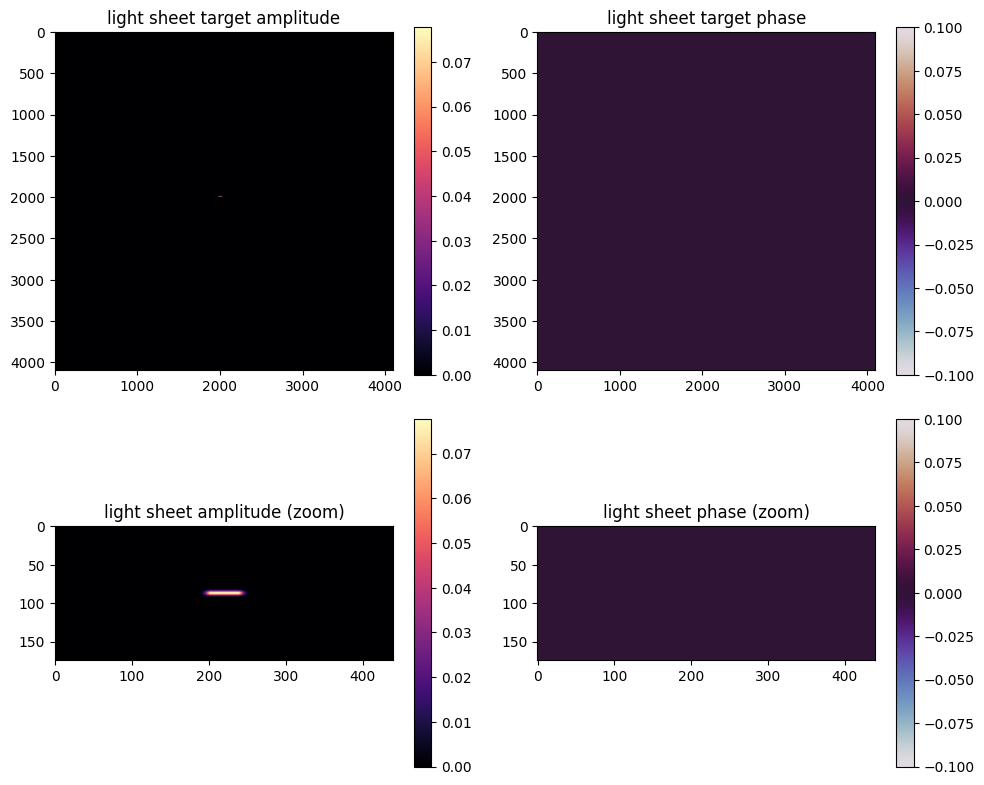


[TARGET] light sheet: flat_width=35px gauss_sigma=2px edge_sigma=5px center=(1997.5,1997.5) shift=198um from zero-order nonzero=52060


In [4]:
# 生成目标光场（light sheet）
# target_center 使用 (row, col) 顺序，基于计算网格中心再整体平移 target_shift_fpx

target_center = (
    (SLM.ImgResY - 1) / 2.0 - target_shift_fpx,
    (SLM.ImgResX - 1) / 2.0 - target_shift_fpx,
)

# 生成目标复振幅（不在函数内部画图，改为这里按 um 统一作图）
targetAmp = SLM.light_sheet_target(
    flat_width=sheet_flat_width,
    gaussian_sigma=sheet_gaussian_sigma,
    angle=sheet_angle,
    edge_sigma=sheet_edge_sigma,
    center=target_center,
    reweight=reweight,
    Plot=False,
)

# 像素参数换算为物理单位（um）
flat_width_um = sheet_flat_width * SLM.Focalpitchx
gauss_sigma_um = sheet_gaussian_sigma * SLM.Focalpitchy
edge_sigma_um = sheet_edge_sigma * SLM.Focalpitchx
center_row0 = (SLM.ImgResY - 1) / 2.0
center_col0 = (SLM.ImgResX - 1) / 2.0
center_um = (
    (target_center[0] - center_row0) * SLM.Focalpitchy,
    (target_center[1] - center_col0) * SLM.Focalpitchx,
)
shift_um = target_shift_fpx * SLM.Focalpitchx

print(
    f"\n[TARGET] light sheet: flat_width={flat_width_um:.1f}um "
    f"gauss_sigma={gauss_sigma_um:.1f}um edge_sigma={edge_sigma_um:.1f}um "
    f"center=({center_um[0]:.1f},{center_um[1]:.1f})um "
    f"shift={shift_um:.1f}um from zero-order "
    f"nonzero={np.count_nonzero(targetAmp)}"
)

# ---------- 用 um 单位作图（全图 + 自动 zoom） ----------
amp = np.abs(targetAmp)
phase = np.angle(targetAmp)
ny, nx = amp.shape

# 像素索引 -> 物理坐标（以零级中心为原点）
x_um = (np.arange(nx) - (nx - 1) / 2.0) * SLM.Focalpitchx
y_um = (np.arange(ny) - (ny - 1) / 2.0) * SLM.Focalpitchy
extent_full = [x_um[0], x_um[-1], y_um[-1], y_um[0]]

# 自动 zoom：用高幅值区域定位主体，避免长尾导致窗口过大
peak = amp.max()
support = amp >= (peak * 0.05) if peak > 0 else np.zeros_like(amp, dtype=bool)
if not np.any(support):
    support = amp > 0
rows, cols = np.where(support)
if rows.size > 0:
    margin = 10
    r0 = max(0, rows.min() - margin)
    r1 = min(ny, rows.max() + margin + 1)
    c0 = max(0, cols.min() - margin)
    c1 = min(nx, cols.max() + margin + 1)
else:
    r0, r1, c0, c1 = 0, ny, 0, nx

amp_zoom = amp[r0:r1, c0:c1]
phase_zoom = phase[r0:r1, c0:c1]
extent_zoom = [x_um[c0], x_um[c1 - 1], y_um[r1 - 1], y_um[r0]]

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(amp, cmap="magma", extent=extent_full, aspect="auto")
plt.colorbar(label="|targetAmp|")
plt.title("light sheet target amplitude")
plt.xlabel("x (um)")
plt.ylabel("y (um)")

plt.subplot(2, 2, 2)
plt.imshow(phase, cmap="twilight", extent=extent_full, aspect="auto")
plt.colorbar(label="phase (rad)")
plt.title("light sheet target phase")
plt.xlabel("x (um)")
plt.ylabel("y (um)")

plt.subplot(2, 2, 3)
plt.imshow(amp_zoom, cmap="magma", extent=extent_zoom, aspect="auto")
plt.colorbar(label="|targetAmp|")
plt.title(f"light sheet amplitude (zoom, {amp_zoom.shape[0]}x{amp_zoom.shape[1]})")
plt.xlabel("x (um)")
plt.ylabel("y (um)")

plt.subplot(2, 2, 4)
plt.imshow(phase_zoom, cmap="twilight", extent=extent_zoom, aspect="auto")
plt.colorbar(label="phase (rad)")
plt.title(f"light sheet phase (zoom, {phase_zoom.shape[0]}x{phase_zoom.shape[1]})")
plt.xlabel("x (um)")
plt.ylabel("y (um)")

plt.tight_layout()
plt.show()
